## 02 · Baseline and ranking model

### Analytical question
Can a learnt ranker beat a transparent rule at putting the providers most likely to buy a lead at the top?

### Evidence so far
Notebook 01: outcomes depend on distance, availability, price gap *and* on notification order.

### Why this approach?
Two baselines (nearest-first = legacy behaviour; a hand-written rule score) are the bar. A logistic regression on pairwise features is the production candidate because it is explainable and cheap; gradient boosting is a ceiling check. `rank_shown` is used in training and fixed to 1 at inference to de-bias the position effect. Split is temporal.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
os.chdir(os.path.abspath('../..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 160)
%matplotlib inline
from project1_matching.src import data, features, baseline, ranker, evaluation
ins, leads, offers, _ = data.clean(*data.load('data/synthetic'))
df = features.build_training_set(leads, ins, offers)
train, test = ranker.temporal_split(df, 0.25)
test = test.copy(); test['s_nearest'] = baseline.nearest_score(test); test['s_rule'] = baseline.rule_score(test)
models = ranker.fit(ranker.make_models(), train)
for n, m in models.items(): test[f'p_{n}'] = ranker.score(m, test)
res = {s: evaluation.ranking_metrics(test, s, k=3) | {'coverage': evaluation.coverage(test, s, 3)} for s in ['s_nearest','s_rule','p_logreg','p_hgb']}
pd.DataFrame(res).T.round(3)

12:52:39 p1.data INFO: providers: 224 -> 220 after de-duplication


12:52:39 p1.data INFO: leads: 3000 -> 2930 after dropping unknown zone


12:52:39 p1.data INFO: offers: 14653 -> 14650 after referential-integrity filter


,precision@3,recall@3,ndcg@3,n_queries,coverage
s_nearest,0.556,0.681,0.667,705.0,0.982
s_rule,0.582,0.711,0.718,705.0,0.986
p_logreg,0.593,0.728,0.736,705.0,0.936
p_hgb,0.588,0.721,0.729,705.0,0.950


### Result / Interpretation
The learnt ranker improves NDCG@3 over the legacy order by a few points and over the rule by ~1 point; gradient boosting adds nothing over logistic regression at this data size. The uplift is modest and honest: within a candidate set of near-equivalent local providers there is limited headroom.

### Decision
Ship logistic regression (D5). The measured gain must be confirmed with an interleaving test — logged data alone cannot fully remove the position confound (limitations.md).

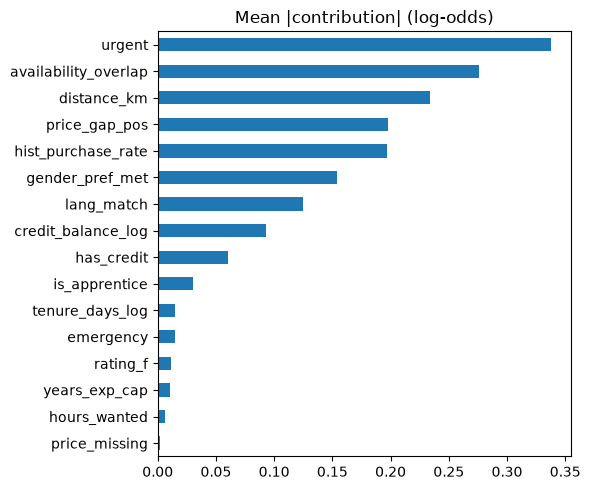

In [2]:
contrib = ranker.logreg_contributions(models['logreg'], test)
contrib.abs().mean().sort_values().plot.barh(figsize=(6,5), title='Mean |contribution| (log-odds)'); plt.tight_layout()

In [3]:
lid = test.lead_id.iloc[0]
ex = test[test.lead_id==lid].sort_values('p_logreg', ascending=False).head(3)
expl = contrib.loc[ex.index].round(2); expl.insert(0,'provider',ex.provider_id.values); expl.insert(1,'p',ex.p_logreg.round(3).values)
expl.T

,10896,10897,10895
provider,P0116,P0056,P0044
p,0.529,0.46,0.316
distance_km,0.25,0.25,0.25
availability_overlap,-0.45,-0.45,-0.45
price_gap_pos,0.18,-0.19,-0.4
price_missing,0.0,0.0,0.0
has_credit,0.03,0.03,0.03
credit_balance_log,0.04,0.12,-0.03
urgent,-0.28,-0.28,-0.28
emergency,-0.01,-0.01,-0.01


### Interpretation
For one lead, the explanation table says *why* provider A outranks B: the columns are additive log-odds contributions, so an ops person can read 'closer, available at the right times, price within budget'. This is the explainability layer that ships with every recommendation.